In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
data=pd.read_csv('StudentsPerformance.csv')

In [3]:
data.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [4]:
data.tail(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
990,male,group E,high school,free/reduced,completed,86,81,75
991,female,group B,some high school,standard,completed,65,82,78
992,female,group D,associate's degree,free/reduced,none,55,76,76
993,female,group D,bachelor's degree,free/reduced,none,62,72,74
994,male,group A,high school,standard,none,63,63,62
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [5]:
data.shape

(1000, 8)

In [6]:
data.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
data.describe(include='object')

,gender,race/ethnicity,parental level of education,lunch,test preparation course
count,1000,1000,1000,1000,1000
unique,2,5,6,2,2
top,female,group C,some college,standard,none
freq,518,319,226,645,642


In [11]:
data.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [12]:
data['parental level of education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [13]:
data['parental level of education'].value_counts()

parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='parental level of education'>

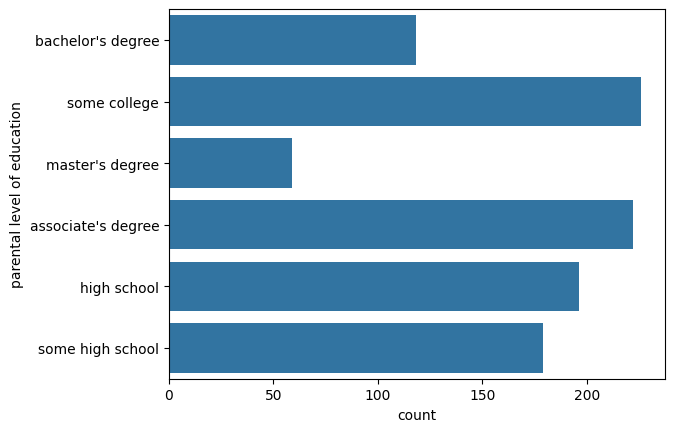

In [14]:
sns.countplot(y='parental level of education',data=data)

<Axes: xlabel='math score', ylabel='reading score'>

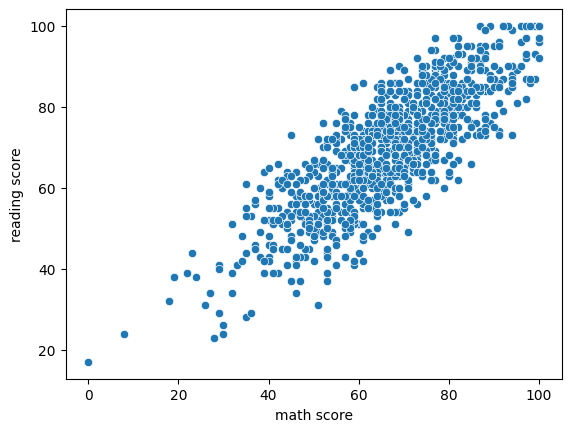

In [15]:
sns.scatterplot(x='math score',y='reading score' ,data=data)

In [16]:
data.corr(numeric_only=True)

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


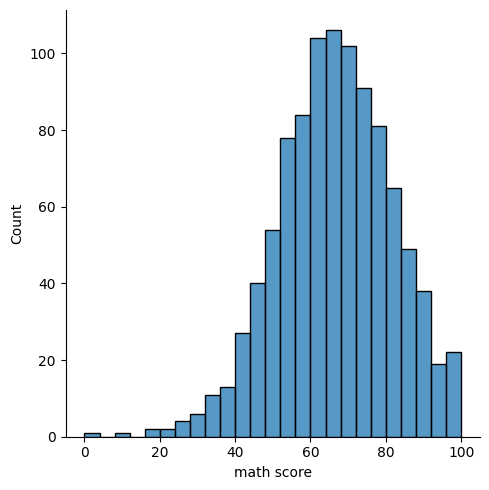

In [17]:
sns.displot(data['math score'],kind='hist')

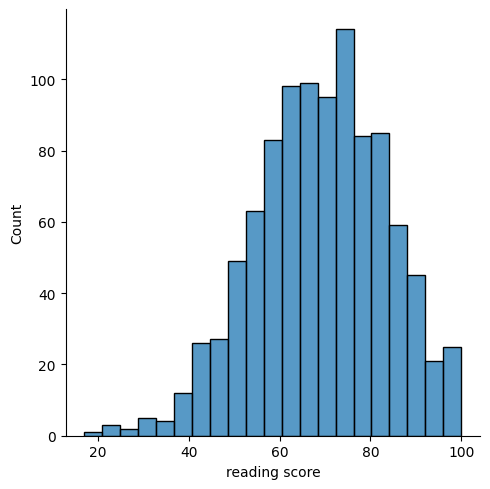

In [18]:
sns.displot(data['reading score'], kind='hist')

In [19]:
data['math score'].skew() #left-skewed

np.float64(-0.27893514909431694)

In [20]:
data['reading score'].skew()  #left-skewed

np.float64(-0.25910451810923063)

<Axes: ylabel='math score'>

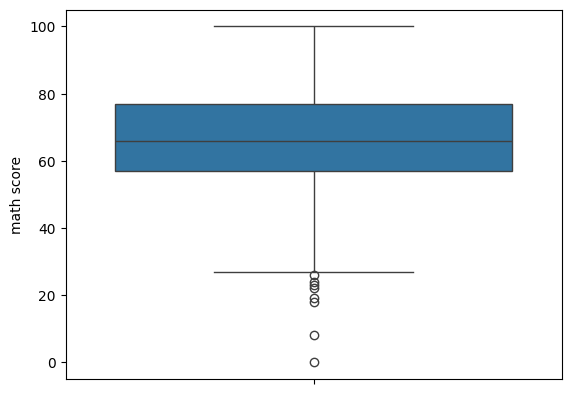

In [21]:
sns.boxplot(data['math score'])

<Axes: ylabel='reading score'>

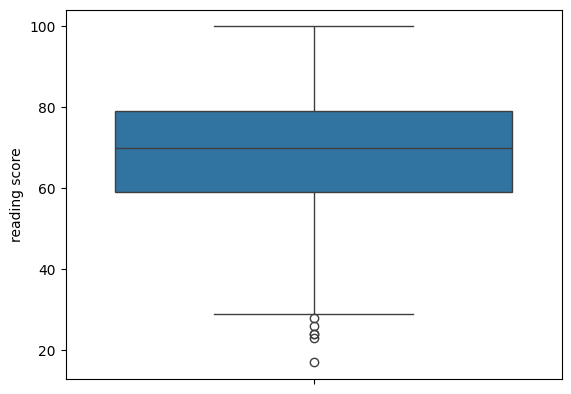

In [22]:
sns.boxplot(data['reading score'])

In [23]:
x=data['math score']
y=data['reading score']
z=data['writing score']

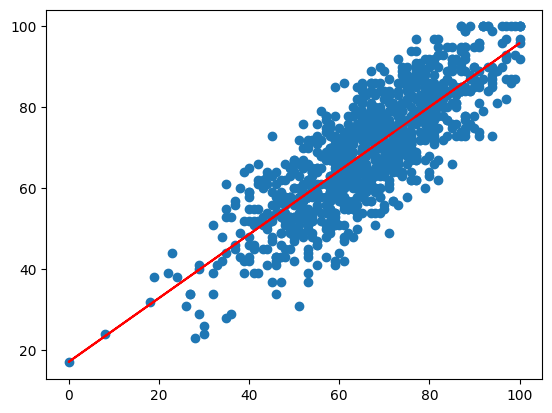

In [24]:
plt.scatter(x,y)
m,b =np.polyfit(x,y,1)
plt.plot(x,m*x+b,'r')

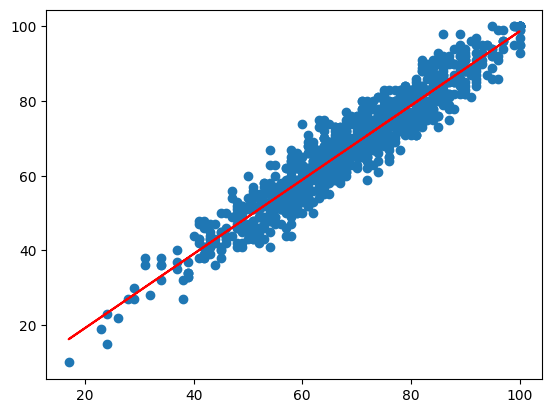

In [25]:
plt.scatter(y,z)
m,b=np.polyfit(y,z,1)
plt.plot(y,m*y+b,'r')


In [26]:
x=data[['math score']]

In [27]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=12)
x_train.shape,x_test.shape,y_test.shape,y_train.shape

((700, 1), (300, 1), (300,), (700,))

In [30]:
from sklearn.linear_model import LinearRegression

In [33]:
lm = LinearRegression()

In [34]:
lm.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
lm.intercept_

np.float64(17.82533410926999)

In [36]:
lm.coef_

array([0.77252005])

In [37]:
y_pred=lm.predict(x_test)


In [38]:
from sklearn.metrics import mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
r_squared=r2_score(y_test,y_pred)
mse,r_squared

(67.90972426339682, 0.6840927537654455)

In [39]:
data1=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
data1

,Actual,Predicted
518,78,68.811657
871,72,71.901738
797,84,71.901738
274,85,85.807099
325,90,81.171978
...,...,...
622,51,62.631497
251,83,72.674258
222,65,60.313937
362,58,57.996377
